POTATO CNN — MODEL EVALUATION
Mounted at /content/drive

Model:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/potato_cnn_combined_best.keras

LOADING TEST DATA
X_test : (446, 224, 224, 3)
y_test : (446,)

LOADING BEST POTATO CNN
✅ Model loaded successfully

TEST SET EVALUATION
Test Loss     : 0.0652
Test Accuracy : 98.21%

Generating predictions...
✅ Predictions generated

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     0.9828    0.9828    0.9828       116
Early_Blight     0.9701    1.0000    0.9848       130
 Late_Blight     0.9898    0.9700    0.9798       200

    accuracy                         0.9821       446
   macro avg     0.9809    0.9843    0.9825       446
weighted avg     0.9822    0.9821    0.9820       446

CONFUSION MATRIX
[[114   0   2]
 [  0 130   0]
 [  2   4 194]]


<Figure size 700x600 with 0 Axes>

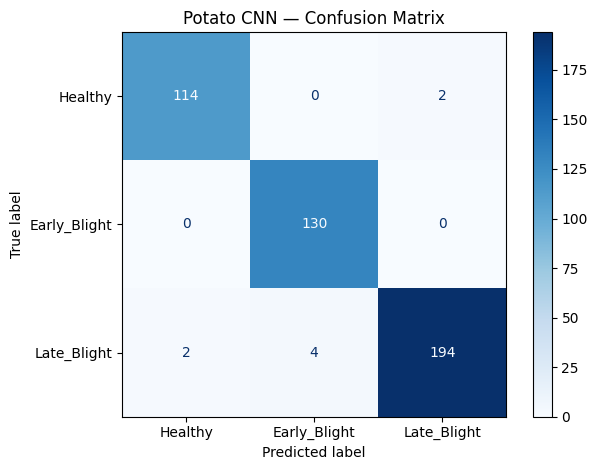


POTATO MODEL EVALUATION COMPLETED
Test Accuracy : 98.21%

Saved files:
1 → /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation/potato_confusion_matrix.png
2 → /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation/potato_evaluation_report.txt

NEXT STEP → POTATO TEST IMAGES


In [1]:
# ================================================================
# POTATO CNN — MODEL EVALUATION
# ================================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("=" * 70)
print("POTATO CNN — MODEL EVALUATION")
print("=" * 70)

# ------------------------------------------------
# 1. DRIVE + PATHS
# ------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

DATA_FILE = os.path.join(
    PROJECT_DIR,
    "3rd Preprocessing",
    "potato_processed_data.npz"
)

MODEL_FILE = os.path.join(
    PROJECT_DIR,
    "6th Trained_Model",
    "potato_cnn_combined_best.keras"
)

EVAL_DIR = os.path.join(
    PROJECT_DIR,
    "5th Model_Evaluation"
)

os.makedirs(EVAL_DIR, exist_ok=True)

print("\nModel:")
print(MODEL_FILE)

# ------------------------------------------------
# 2. LOAD TEST DATA
# ------------------------------------------------

print("\n" + "=" * 70)
print("LOADING TEST DATA")
print("=" * 70)

data = np.load(DATA_FILE)

X_test = data["X_test"]
y_test = data["y_test"]

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------
# 3. LOAD BEST TRAINED MODEL
# ------------------------------------------------

print("\n" + "=" * 70)
print("LOADING BEST POTATO CNN")
print("=" * 70)

model = tf.keras.models.load_model(MODEL_FILE)

print("✅ Model loaded successfully")

# ------------------------------------------------
# 4. TEST LOSS + ACCURACY
# ------------------------------------------------

print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

# ------------------------------------------------
# 5. PREDICTIONS
# ------------------------------------------------

print("\nGenerating predictions...")

probabilities = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(probabilities, axis=1)

print("✅ Predictions generated")

# ------------------------------------------------
# 6. CLASS NAMES
# ------------------------------------------------

class_names = [
    "Healthy",
    "Early_Blight",
    "Late_Blight"
]

# ------------------------------------------------
# 7. CLASSIFICATION REPORT
# ------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

# ------------------------------------------------
# 8. CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

# ------------------------------------------------
# 9. SAVE CONFUSION MATRIX IMAGE
# ------------------------------------------------

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Potato CNN — Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(
    EVAL_DIR,
    "potato_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------
# 10. SAVE TEXT REPORT
# ------------------------------------------------

report_path = os.path.join(
    EVAL_DIR,
    "potato_evaluation_report.txt"
)

with open(report_path, "w") as f:

    f.write("POTATO CNN — MODEL EVALUATION\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Test Images : {len(y_test)}\n")
    f.write(f"Test Loss   : {test_loss:.4f}\n")
    f.write(f"Test Accuracy : {test_accuracy * 100:.2f}%\n\n")

    f.write("Classes:\n")
    f.write("0 = Healthy\n")
    f.write("1 = Early_Blight\n")
    f.write("2 = Late_Blight\n\n")

    f.write("Classification Report\n")
    f.write("=" * 60 + "\n")
    f.write(report)

    f.write("\n\nConfusion Matrix\n")
    f.write("=" * 60 + "\n")
    f.write(str(cm))

# ------------------------------------------------
# 11. FINAL RESULT
# ------------------------------------------------

print("\n" + "=" * 70)
print("POTATO MODEL EVALUATION COMPLETED")
print("=" * 70)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("\nSaved files:")

print("1 →", cm_path)
print("2 →", report_path)

print("\n" + "=" * 70)
print("NEXT STEP → POTATO TEST IMAGES")
print("=" * 70)